In [1]:
import pandas as pd
import re
from difflib import SequenceMatcher
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import ast

In [2]:
cwes = ["CWE-22", "CWE-89", "CWE-79"]
# cwes = ["CWE-79"]
models = ['mixtral-8x7b-32768', 'mixtral-8x22b-65536', "llama-3-70b-8192", "gpt-3.5-turbo", "gpt-4-turbo", "gpt-4o"]
# models = ['mixtral-8x7b-32768']
# models = ["gpt-3.5-turbo"]

model_renames = {
    "mixtral-8x7b-32768": "mixtral-8x7b",
    "mixtral-8x22b-65536": "mixtral-8x22b",
    "llama3-70b-8192": "llama3-70b"
}

data_path = '../../1_all_files_analysis'

max_bug_pos_in_data = 25000
threshold_step = 500

- Usage -> define your models and skip to execution part
- The files must have structure data-CWE-XX-model.csv with following 3 headers: file_id, model_output, type (buggy, not_buggy)

# Functions

## importing CVS

In [3]:
def import_csv(cwe_id, model):

    def _check_files(df_data, df_files):
        # check if df_data has 3 columns: file_Id with integers, model_output with text and type with buggy/not_buggy
        required_columns = {
            'file_id': 'int64',  # assuming file_id should be an integer type
            'model_output': 'object', # in pd text
            'type': 'object'  
        }

        # Check if all required columns are in df_data and have the correct data type
        for column, dtype in required_columns.items():
            assert column in df_data.columns, f"Missing column: {column}"
            assert df_data[column].dtype == dtype, f"Incorrect dtype for {column}: expected {dtype}, found {df_data[column].dtype}"

        # Check if 'type' column has only 'buggy' or 'not_buggy'
        valid_types = ['buggy', 'not_buggy']
        assert df_data['type'].isin(valid_types).all(), "Column 'type' contains invalid entries"

        
        # Expected checks
        file_ids_data = df_data['file_id'].value_counts()
        file_ids_files = df_files['file_id'].unique()

        # Check for each file_id if it appears twice in the data
        problems = []
        for file_id in file_ids_files:
            if file_id not in file_ids_data or file_ids_data[file_id] != 2:
                problems.append(file_id)
        
        # Check if the number of records in data is double the number of file_ids in files
        if len(df_data) != 2 * len(df_files):
            print(f"Data count mismatch: Expected {2 * len(df_files)}, got {len(df_data)}.")

        if problems:
            print(f"Some file_ids are missing the required number of entries in the data:")
            for file_id in problems:
                count = file_ids_data[file_id] if file_id in file_ids_data else 0

                # Uncomment to see which files are exactly missing
                # print(f"file_id {file_id}: Expected 2, Found {count}")
        else:
            print("All file_ids have the correct number of entries.")

    # File paths
    data_csv = f"{data_path}/data/data_{cwe_id}_{model}.csv"
    files_csv = f"{data_path}/files_{cwe_id}.csv"

    # Load data
    df_data = pd.read_csv(data_csv)
    df_files = pd.read_csv(files_csv)

    _check_files(df_data, df_files)

    # Continue processing as before
    df = pd.merge(df_data, df_files, on='file_id', how='left')
    df['file_to_use'] = df.apply(lambda row: row['file_before'] if row['type'] == 'buggy' else row['file_after'], axis=1)
    df['file_to_use'] = list(map('\n'.join, map(ast.literal_eval, df['file_to_use'].tolist()))) # convert list of lines into entire file
    df = df[['file_to_use', 'type', 'model_output', 'patch']]

    return df


## Classification

In [4]:
# Functions to work towards classification
bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
bug_line_pattern_simple = re.compile(r'(Bugged)?[ -]*(Line|BL) *[:#]', re.IGNORECASE)
# enhanced regrex which removes notes and matches everything up to bug found: -> not working for notes etc, but takes  abckticks into account
# bug_line_pattern = re.compile(r'BL:\s*(?:`([^`]+)`|([^`]*?))(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
# -> now logic defines in extract_bug_lines logic

def extract_code_or_return_original(text):
    # This regex matches text enclosed in triple backticks, capturing the content after the initial language specifier.
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        # No code block found, return the original text
        return text

    # If matches are found, extract and return them
    results = []
    for match in matches:
        # Extract the code content, excluding the language name
        results.append(match.group(2).strip())

    # Join extracted code blocks with newlines, if there are multiple blocks
    return "\n".join(results)

def clean_whitespace(text):
    # Replace all newlines with a single space
    text = text.replace('\n', ' ')
    # Replace all sequences of whitespace with a single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def remove_spaces(text):
    return text.replace(' ', '')

def get_removed_lines(patch):
    # Extract lines starting with -
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    # Remove the leading - character from each line
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    # todo maybe not right? -> look then into df's
    # if there is second from the end take it otherwise the last one

    # TODO this is fix for second prompt where we have no BUG FOUND: -> maybe we should have a better check for this
    if(len(re.split(bug_line_pattern, model_output)) < 3):
        bug_line = re.split(bug_line_pattern_simple, model_output)[-1].strip()
    else:
        bug_line = re.split(bug_line_pattern, model_output)[-2].strip()

    # bug_line = re.split(bug_line_pattern, model_output, 1)[-2]
    bug_line = extract_code_or_return_original(bug_line).strip()

    # if there is a string which is in ` ` extract it, otherwise use as it is
    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)  # Return content inside the backticks

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    _has_bug_line = bool(bug_line_pattern.search(model_output)) #or bool(bug_line_pattern_simple.search(model_output))

    # TODO might need some improval on this 
    if not _has_bug_line:
        return False
    
    # extract bug line
    bug_line = extract_bug_line(model_output)
    # strip remove spaces
    bug_line = remove_spaces(clean_whitespace(bug_line)).strip()

    if(len(bug_line) == 0):
        return False

    if(_has_bug_line and ('BL: None'.lower() not in model_output.lower() or "BUG FOUND: NO".lower() not in model_output.lower())):
        return True
    
    if code and code != model_output:
        return True

def clean_patch(patch):
    # remova all + and - at the behinning of lines
    return re.sub(r'^[+-]', '', patch, flags=re.MULTILINE)

def classify(record):
    type = record['type']
    patch = record['patch']
    model_output = record['model_output']

    classification = None
    bug_line = None
    patch_removal = None

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    # Check for matches
    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    # stronger conditions -> lets rely purely on model_output under Bug found
    if type == 'not_buggy':
        if has_bug_true_indication: 
            classification = 'FP'
        else:
            classification = 'TN'
    elif type == 'buggy' and has_bug_false_indication: 
        classification = 'FN'
    else:
        # weaker decision based in bugged_line
        if not _has_bug_line:
            classification = 'FN'
        else:
            bug_line = remove_spaces(extract_bug_line(model_output))
            # patch_removal = remove_spaces(clean_whitespace(get_removed_lines(patch)))
            cleaned_patch = remove_spaces(clean_whitespace(clean_patch(patch)))

            bug_line_in_patch = bug_line in cleaned_patch

            if (len(bug_line) > 0 and bug_line_in_patch):
                classification = 'TP'
            else:
                classification = 'FN' 
        
    # return panda seried for easier debugging
    return pd.Series([classification, bug_line, patch_removal])

def get_patch_line_list(patch_text):
    patch_line_regexp = r'@@ -(\d+,\d+) \+(\d+,\d+) @@'

    matches = re.findall(patch_line_regexp, patch_text)
    line_numbers = [int(match[0].split(',')[0]) for match in matches]
    return line_numbers

def get_first_patchline(patch):
    # Regular expression pattern to match the first -1 number in the diff
    lines = get_patch_line_list(patch)

    if(lines):
        return lines[0]

    return None  # Return None if no match is found to indicate the absence of the expected pattern

def extract_removed_lines(patch_text):
    lines = patch_text.split('\n')
    removed_lines = []
    current_line_number = 0

    for line in lines:
        # Match the hunk header to find the starting line number
        if line.startswith('@@'):
            match = re.match(r'@@ -(\d+),(\d+) \+(\d+),(\d+) @@', line)
            if match:
                current_line_number = int(match.group(1)) - 1
            continue

        # Increment line number for original file lines
        if line.startswith('-') or (not line.startswith('+') and not line.startswith('@')):
            current_line_number += 1

        # Process only lines that start with '-'
        if line.startswith('-'):
            removed_lines.append((current_line_number, line[1:].strip()))

    return removed_lines

## Logistic Regression

In [5]:
from sklearn.metrics import roc_auc_score, roc_curve

def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    # Prepare data: Add a constant term for the intercept
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    
    # Fit logistic regression model
    model = sm.Logit(y, X).fit(disp=0)  # disp=0 suppresses fit information
    
    # Generate predictions for a range of input values
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 300)
    x_values_with_const = sm.add_constant(x_values)
    y_probs = model.predict(x_values_with_const)

    # Set label for plot (includes model details)
    label_dict = {
        "CWE-22": "CWE-22",
        "CWE-89": "CWE-89",
        "CWE-79": "CWE-79"
    }
    
    # Define line styles for each CWE for differentiation
    line_styles = {
        'CWE-22': 'solid',  # solid line
        'CWE-89': 'dashed', # dashed line
        'CWE-79': 'dashdot' # dash-dot line
    }
    
    # plot_label = f"{label_dict[label]} (p={coefficients[x_col]:.5f}, AUC={auc:.3f}, Intercept = {model.params['const']:.4f})"
    plot_label = label_dict[label] + (f" (p={model.pvalues[x_col]:.3f})" if model.pvalues[x_col] > 0.05 else "")
    
    # Plot
    ax.plot(x_values, y_probs, label=plot_label, linestyle=line_styles[label], color=color, linewidth=2)
    
    # Plot actual points
    individual_probs = model.predict(X)
    ax.scatter(data[x_col], individual_probs, color=color, alpha=0.1)  # semi-transparent

    # # Select five points to label and collect for DataFrame
    # sample_indices = np.linspace(0, len(data) - 1, 5, dtype=int)
    # points_df = pd.DataFrame({
    #     'x_value': data.iloc[sample_indices][x_col],
    #     'probability': individual_probs.iloc[sample_indices],
    #     'plot_name': label
    # }).reset_index(drop=True)

    # # Annotate the plot with these probabilities
    # for i, row in points_df.iterrows():
    #     ax.annotate(f'{row["probability"]:.2f}', 
    #                 (row['x_value'], row['probability']),
    #                 textcoords="offset points", 
    #                 xytext=(0,10), 
    #                 ha='center', 
    #                 fontsize=8, 
    #                 color=color)
    
    auc = roc_auc_score(y, individual_probs) # Calculate AUC using actual data
    intercept = model.params['const']
    coefficient = model.params[x_col]
    odds_ratios = np.exp(intercept)
    p_value = model.pvalues[x_col]
    return p_value, intercept, odds_ratios, auc, coefficient

def get_bug_pos(file_content, patch):
    patch_lines = get_patch_line_list(patch)
    if not patch_lines:
        return None, None, None
    file_content_lines = file_content.split('\n')
    min_bug_pos = len('\n'.join(file_content_lines[:patch_lines[0]]))
    max_bug_pos = len('\n'.join(file_content_lines[:patch_lines[-1]]))
    avg_bug_pos = (min_bug_pos+max_bug_pos)//2

    return min_bug_pos, max_bug_pos, avg_bug_pos

In [6]:
def prepare_df(df):
    df[['classification', 'bug_line', 'patch_removal']] = df.apply(classify, axis=1)

    df['bug_pos'] = df.apply(lambda row: get_bug_pos(row['file_to_use'], row['patch'])[0], axis=1) #using 0 for min position


    df['patch_removal'] = df.apply(lambda row: get_removed_lines(row['patch']), axis=1)
    df['match_score_pure_removal'] = df.apply(lambda row: SequenceMatcher(None, row['patch_removal'], row['bug_line']).ratio() if row["bug_line"] is not None else 0, axis=1)

    df['match_score'] = df.apply(lambda row: SequenceMatcher(None, row['patch'], row['bug_line']).ratio() if row["bug_line"] is not None else 0, axis=1)

    #calculate important stats for regression 
    df['file_length_chars'] = df.apply(lambda row: len(row['file_to_use']), axis=1)
    df['patch_line_first'] = df.apply(lambda row: get_first_patchline(row['patch']), axis=1)
    df['removed_lines'] = df.apply(lambda row: extract_removed_lines(row['patch']), axis=1)

    return df

import csv
def main():
    target_variable = 'classification_TP'
    fontsize = 14
    file_length_chars_lr_stats = []
    bug_position_lr_stats = []
    
    for j in range(max_bug_pos_in_data//threshold_step-1, 0, -1):
        size_threshold = j*threshold_step

        # Define figure size and number of subplots based on the number of models
        fig, big_axes = plt.subplots(nrows=2, ncols=len(models), figsize=(16, len(models)), dpi=100, sharex='row', sharey='all')
        fig.subplots_adjust(hspace=0.4, wspace=0.3)  # Adjust spacing between plots
        colors = plt.cm.viridis(np.linspace(0, 1, len(cwes)))  # Generate a color array

        for col, model in enumerate(models):
            for i, cwe in enumerate(cwes):
                df = import_csv(cwe, model)
                df = prepare_df(df)
                df = pd.get_dummies(df, columns=['classification'], drop_first=False)
                df = df.dropna(subset=['bug_pos', 'file_length_chars'])
                df = df[(df['classification_TP'] == 1) | (df['classification_FN'] == 1)]
                
                #df.to_csv('./data.csv', index=False)

                ax1 = big_axes[0, col]
                ax2 = big_axes[1, col]

                #df = df[df['bug_pos'] <= size_threshold]
                df = df[df['file_length_chars'] <= size_threshold]
                
                print(f'For {cwe}, {model} has {len(df)} datapoints with files smaller than {size_threshold} characters.')

                try:
                    p_value, intercept, odds_ratios, auc, coefficient = plot_logistic_regression(df, 'file_length_chars', target_variable, cwe, ax1, colors[i])
                    file_length_chars_lr_stats.append({
                        'CWE-ID':cwe, 
                        'file_size':size_threshold, 
                        'model': model,
                        'p_value': p_value,
                        'coefficient': coefficient,
                        'odds_ratios': odds_ratios,
                        'auc': auc,
                        'intercept': intercept,
                    })
                    p_value, intercept, odds_ratios, auc, coefficient = plot_logistic_regression(df, 'bug_pos', target_variable, cwe, ax2, colors[i])
                    bug_position_lr_stats.append({
                        'CWE-ID':cwe, 
                        'file_size':size_threshold, 
                        'model': model,
                        'p_value': p_value,
                        'coefficient': coefficient,
                        'odds_ratios': odds_ratios,
                        'auc': auc,
                        'intercept': intercept,
                    })

                    # Setting titles, labels, and legends compactly
                    # Renaming models
                    ax1.set_title(f'{model_renames.get(model,model)}', fontsize=fontsize)
                    #ax2.set_title(model, fontsize=10)
                    ax1.set_xlabel('File Size', fontsize=fontsize)
                    ax2.set_xlabel('Bug Position', fontsize=fontsize)
                    if col == 0:
                        ax1.set_ylabel('Detection Probability', fontsize=fontsize)
                        ax2.set_ylabel('Detection Probability', fontsize=fontsize)
                    ax1.legend(fontsize=10)
                    ax2.legend(fontsize=10)
                except Exception as e:
                    print('Error:', e)

        plt.tight_layout()
        plt.savefig(f"./logistic_regression_t={size_threshold}.pdf")
        plt.show()
        
    # Writing to a CSV file
    with open('./file_length_chars_lr_stats.csv', mode='w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=list(file_length_chars_lr_stats[0].keys()))
        writer.writeheader()
        writer.writerows(file_length_chars_lr_stats)
        
    with open('./bug_position_lr_stats.csv', mode='w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=list(bug_position_lr_stats[0].keys()))
        writer.writeheader()
        writer.writerows(bug_position_lr_stats)
            

# Execution

All file_ids have the correct number of entries.
For CWE-22, mixtral-8x7b-32768 has 94 datapoints with files smaller than 24500 characters.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, mixtral-8x7b-32768 has 113 datapoints with files smaller than 24500 characters.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-79, mixtral-8x7b-32768 has 468 datapoints with files smaller than 24500 characters.
All file_ids have the correct number of entries.


...

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-22, gpt-4o has 94 datapoints with files smaller than 24500 characters.
All file_ids have the correct number of entries.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, gpt-4o has 116 datapoints with files smaller than 24500 characters.
All file_ids have the correct number of entries.
For CWE-79, gpt-4o has 469 datapoints with files smaller than 24500 characters.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


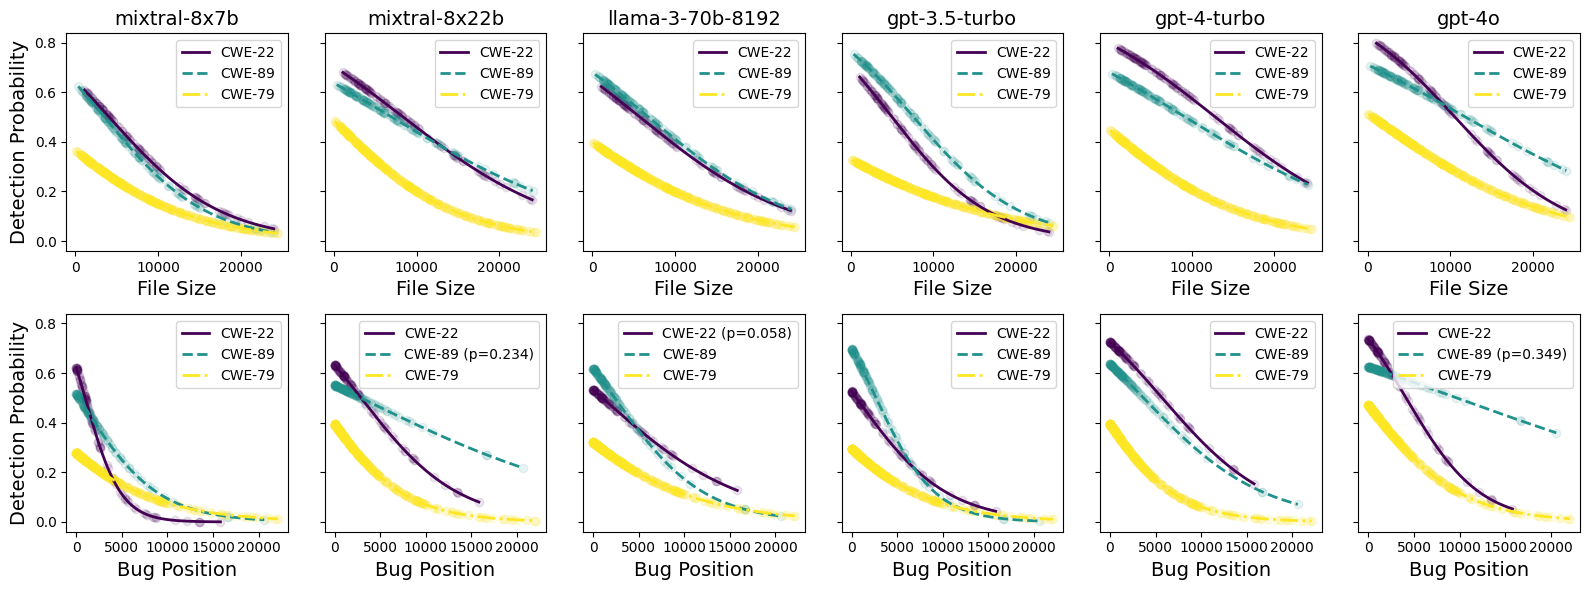

All file_ids have the correct number of entries.
For CWE-22, mixtral-8x7b-32768 has 94 datapoints with files smaller than 24000 characters.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, mixtral-8x7b-32768 has 112 datapoints with files smaller than 24000 characters.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-79, mixtral-8x7b-32768 has 464 datapoints with files smaller than 24000 characters.
All file_ids have the correct number of entries.


...

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-22, gpt-4o has 94 datapoints with files smaller than 24000 characters.
All file_ids have the correct number of entries.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, gpt-4o has 115 datapoints with files smaller than 24000 characters.
All file_ids have the correct number of entries.
For CWE-79, gpt-4o has 465 datapoints with files smaller than 24000 characters.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


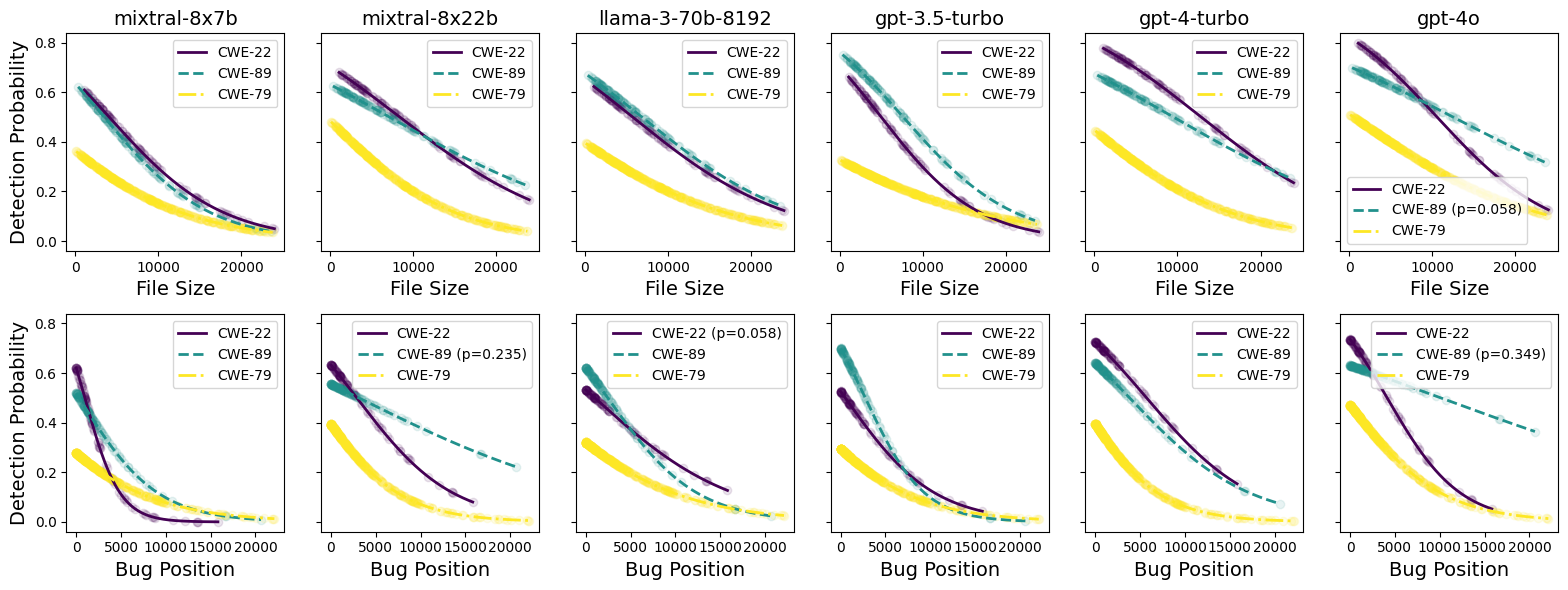

All file_ids have the correct number of entries.
For CWE-22, mixtral-8x7b-32768 has 92 datapoints with files smaller than 23500 characters.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, mixtral-8x7b-32768 has 111 datapoints with files smaller than 23500 characters.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-79, mixtral-8x7b-32768 has 462 datapoints with files smaller than 23500 characters.
All file_ids have the correct number of entries.


...

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-22, gpt-4o has 92 datapoints with files smaller than 23500 characters.
All file_ids have the correct number of entries.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, gpt-4o has 114 datapoints with files smaller than 23500 characters.
All file_ids have the correct number of entries.
For CWE-79, gpt-4o has 463 datapoints with files smaller than 23500 characters.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


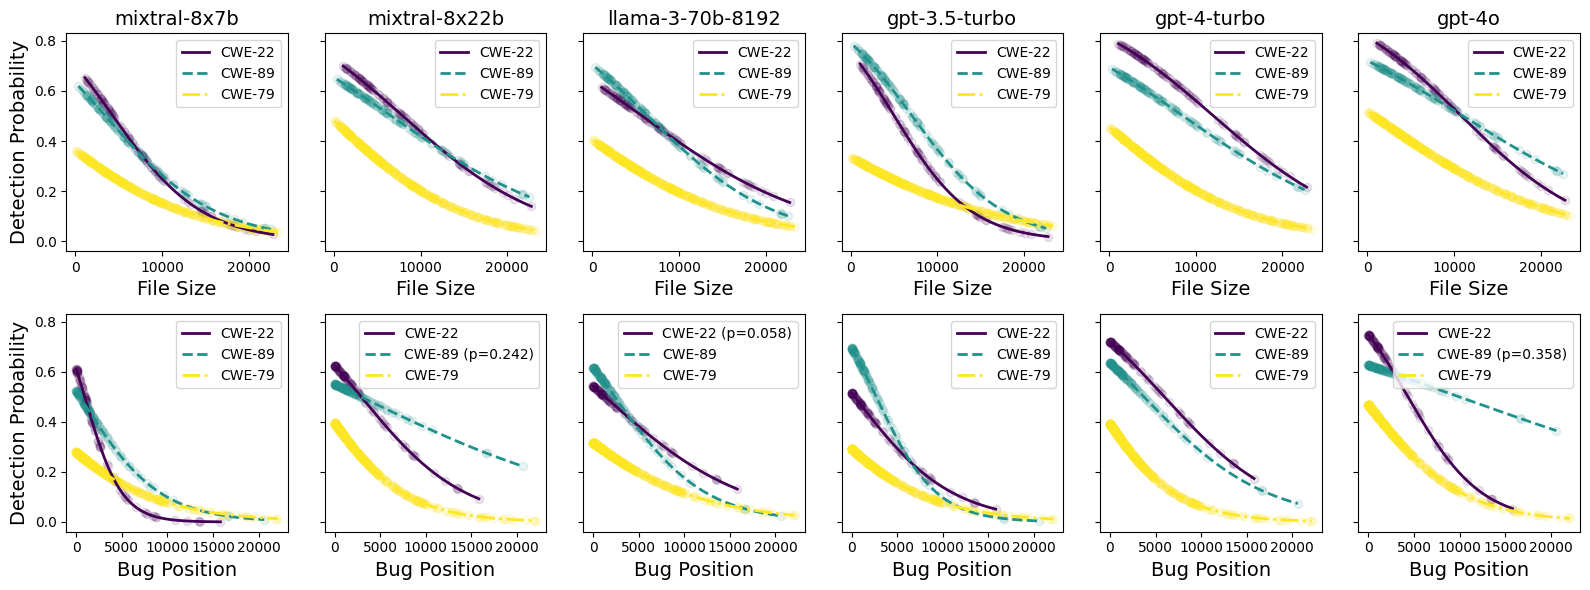

All file_ids have the correct number of entries.
For CWE-22, mixtral-8x7b-32768 has 92 datapoints with files smaller than 23000 characters.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, mixtral-8x7b-32768 has 111 datapoints with files smaller than 23000 characters.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-79, mixtral-8x7b-32768 has 461 datapoints with files smaller than 23000 characters.
All file_ids have the correct number of entries.


...

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-22, gpt-4o has 92 datapoints with files smaller than 23000 characters.
All file_ids have the correct number of entries.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, gpt-4o has 114 datapoints with files smaller than 23000 characters.
All file_ids have the correct number of entries.
For CWE-79, gpt-4o has 462 datapoints with files smaller than 23000 characters.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


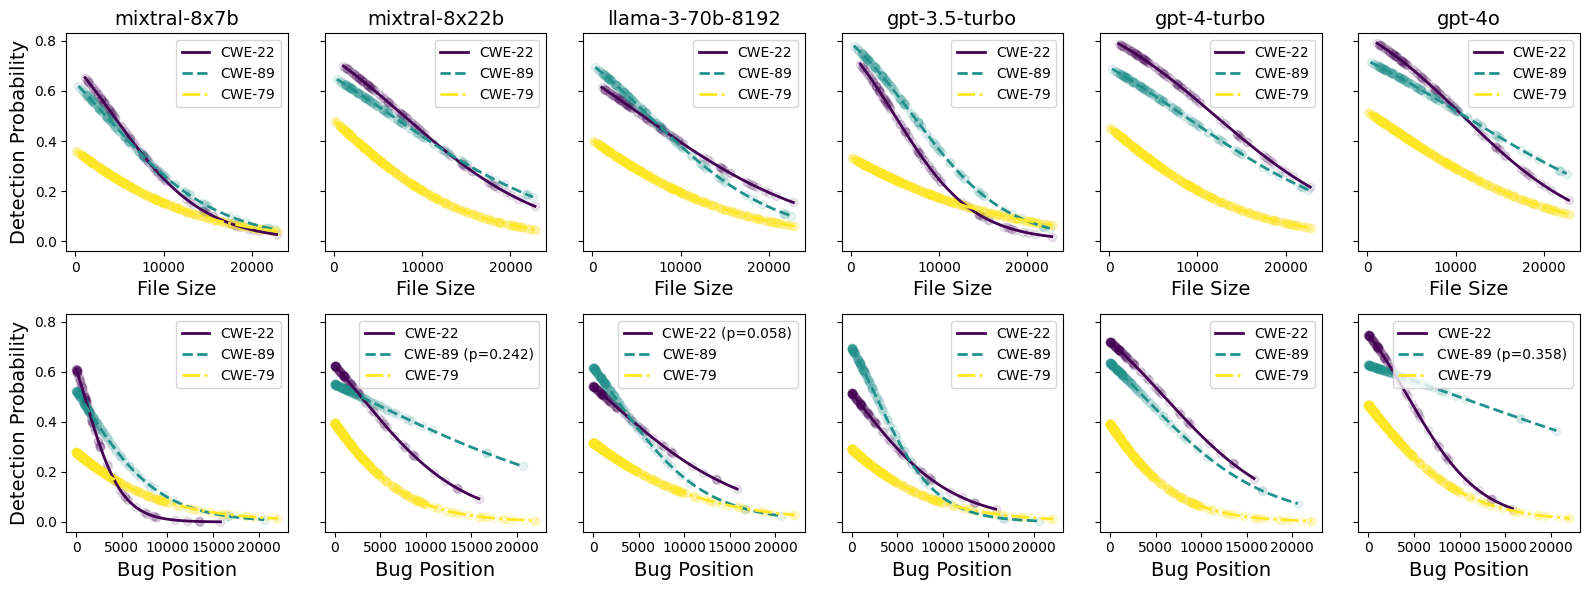

All file_ids have the correct number of entries.
For CWE-22, mixtral-8x7b-32768 has 91 datapoints with files smaller than 22500 characters.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, mixtral-8x7b-32768 has 110 datapoints with files smaller than 22500 characters.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-79, mixtral-8x7b-32768 has 457 datapoints with files smaller than 22500 characters.
All file_ids have the correct number of entries.


...

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-22, gpt-4o has 91 datapoints with files smaller than 22500 characters.
All file_ids have the correct number of entries.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, gpt-4o has 113 datapoints with files smaller than 22500 characters.
All file_ids have the correct number of entries.
For CWE-79, gpt-4o has 458 datapoints with files smaller than 22500 characters.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


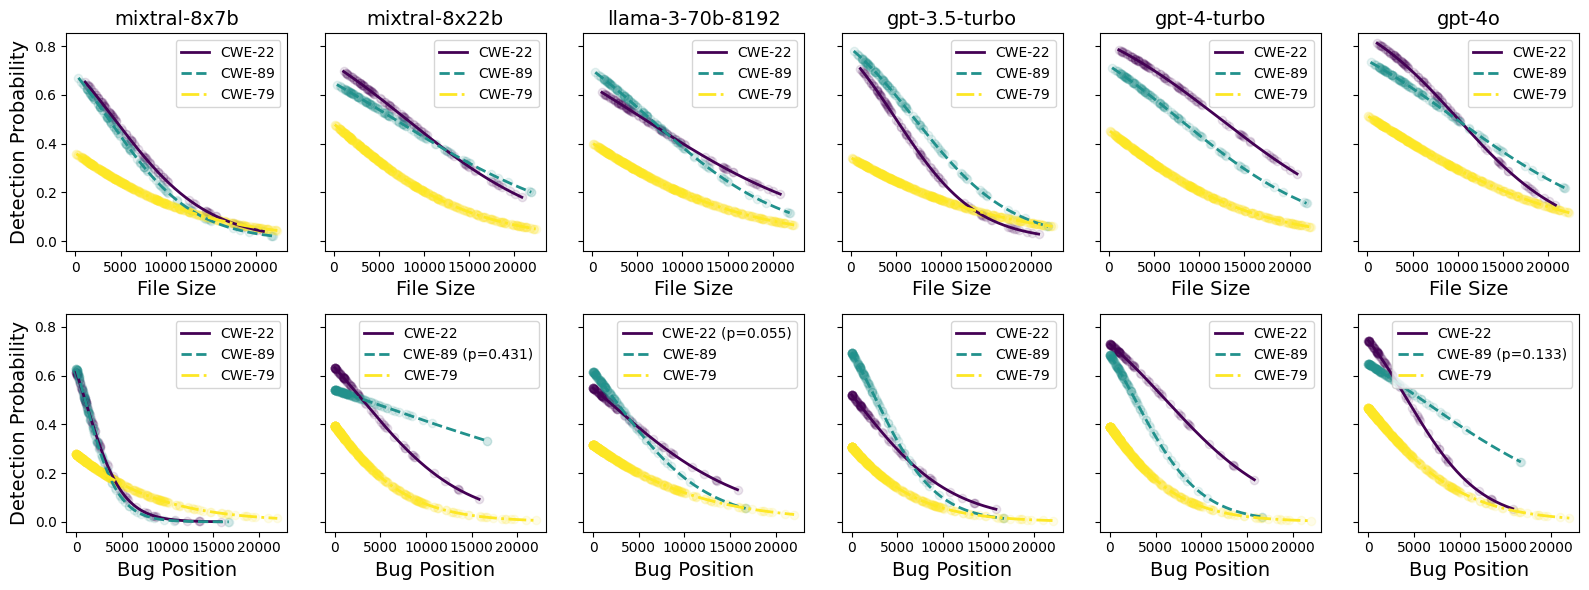

All file_ids have the correct number of entries.
For CWE-22, mixtral-8x7b-32768 has 91 datapoints with files smaller than 22000 characters.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, mixtral-8x7b-32768 has 110 datapoints with files smaller than 22000 characters.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-79, mixtral-8x7b-32768 has 453 datapoints with files smaller than 22000 characters.
All file_ids have the correct number of entries.


...

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-22, gpt-4o has 91 datapoints with files smaller than 22000 characters.
All file_ids have the correct number of entries.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, gpt-4o has 113 datapoints with files smaller than 22000 characters.
All file_ids have the correct number of entries.
For CWE-79, gpt-4o has 454 datapoints with files smaller than 22000 characters.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


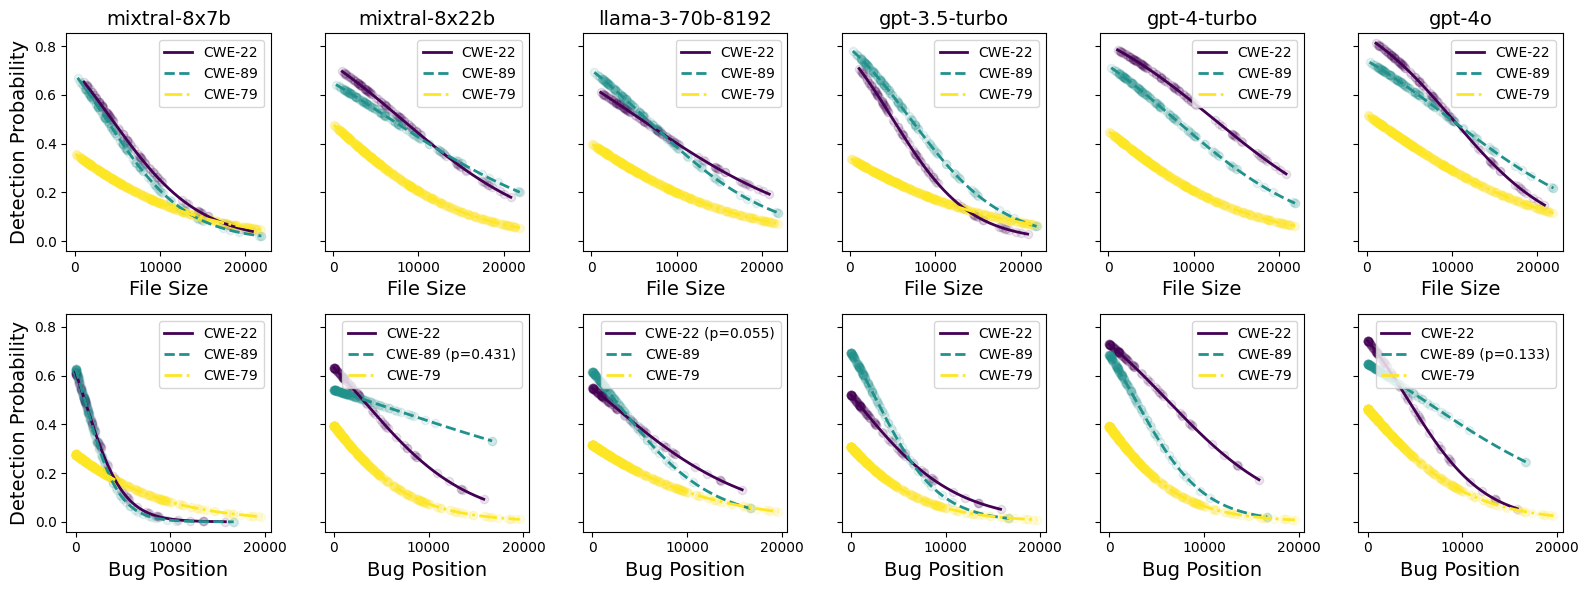

All file_ids have the correct number of entries.
For CWE-22, mixtral-8x7b-32768 has 91 datapoints with files smaller than 21500 characters.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, mixtral-8x7b-32768 has 107 datapoints with files smaller than 21500 characters.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-79, mixtral-8x7b-32768 has 451 datapoints with files smaller than 21500 characters.
All file_ids have the correct number of entries.


...

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-22, gpt-4o has 91 datapoints with files smaller than 21500 characters.
All file_ids have the correct number of entries.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, gpt-4o has 110 datapoints with files smaller than 21500 characters.
All file_ids have the correct number of entries.
For CWE-79, gpt-4o has 452 datapoints with files smaller than 21500 characters.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


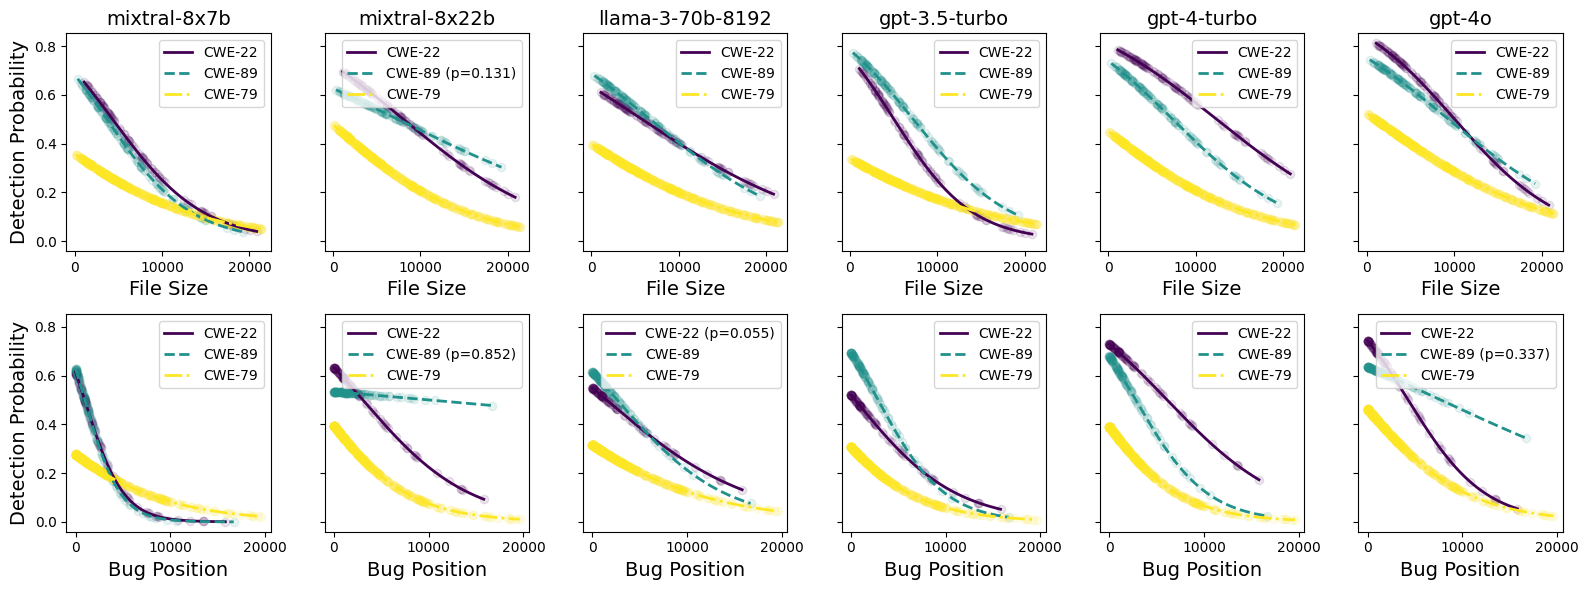

All file_ids have the correct number of entries.
For CWE-22, mixtral-8x7b-32768 has 91 datapoints with files smaller than 21000 characters.
Data count mismatch: Expected 292, got 287.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, mixtral-8x7b-32768 has 107 datapoints with files smaller than 21000 characters.
Data count mismatch: Expected 1086, got 1084.
Some file_ids are missing the required number of entries in the data:


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-79, mixtral-8x7b-32768 has 445 datapoints with files smaller than 21000 characters.
All file_ids have the correct number of entries.


...

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-22, gpt-4o has 91 datapoints with files smaller than 21000 characters.
All file_ids have the correct number of entries.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


For CWE-89, gpt-4o has 110 datapoints with files smaller than 21000 characters.
All file_ids have the correct number of entries.
For CWE-79, gpt-4o has 446 datapoints with files smaller than 21000 characters.


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1819: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1872: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q*np.dot(X,params))))


In [ ]:
main()

# Print all Data

In [ ]:
def concatenate_and_save(models, cwes):
    """
    Concatenates multiple dataframes with added model and CWE columns, and saves the result to a CSV file.
    
    Args:
    models (list): A list of model names.
    cwes (list): A list of CWE identifiers.
    import_csv (function): A function to import a dataframe given a cwe and model.
    prepare_df (function): A function to perform initial cleaning and preparation on the dataframe.
    """
    df_list = []  # List to hold each processed dataframe
    
    # Loop through each model and cwe combination
    for model in models:
        for cwe in cwes:
            df = import_csv(cwe, model)  # Import the dataframe
            df = prepare_df(df)          # Prepare the dataframe
            df = pd.get_dummies(df, columns=['classification'], drop_first=False)  # One-hot encode the 'classification'
            df = df.dropna(subset=['bug_pos', 'file_length_chars'])  # Drop rows with NaN in specified columns
            
            # Filter rows based on 'classification_TP' or 'classification_FN'
            df = df[(df['classification_TP'] == 1) | (df['classification_FN'] == 1)]
            
            # Add 'model' and 'cwe' as new columns
            df['model'] = model
            df['CWE_ID'] = cwe
            
            # Append the processed dataframe to the list
            df_list.append(df)
    
    # Concatenate all dataframes in the list
    final_df = pd.concat(df_list, ignore_index=True)
    
    final_df = final_df[['classification_TP', 'classification_FN', 'CWE_ID', 'model', 'file_length_chars', 'bug_pos']]
    # Filtering the dataframe to include only relevant rows for logistic regression
    final_df = final_df.dropna(subset=['file_length_chars', 'bug_pos'])  # Ensure no NaN values in necessary columns
    print(final_df.columns)
    
    # Save the concatenated dataframe to a CSV file
    final_df.to_csv('../real_data.csv', index=False)
    
    return final_df

# Example usage:
# models = ['model1', 'model2', ...]
# cwes = ['CWE-79', 'CWE-89', ...]
final_df = concatenate_and_save(models, cwes)